In [1]:
import sys
import git
import pathlib

# Set up the PROJ_ROOT variable
PROJ_ROOT_PATH = pathlib.Path(git.Repo('.', search_parent_directories=True).working_tree_dir)
PROJ_ROOT =  str(PROJ_ROOT_PATH)
if PROJ_ROOT not in sys.path:
    sys.path.append(PROJ_ROOT)

# Explicitly add the current notebook's directory
CURRENT_DIR = str(pathlib.Path().absolute())
if CURRENT_DIR not in sys.path:
    sys.path.insert(0, CURRENT_DIR)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors
%matplotlib inline  

In [3]:
from library.utils import fontstyle, style_map

In [4]:
from collections import defaultdict
import sinter

In [5]:
# Load stim stats

csv_filename = PROJ_ROOT_PATH / "notebooks" / "ler" / "ler_2q.csv"

stats = sinter.read_stats_from_csv_files(csv_filename)
print(f"Loaded {len(stats)} simulation tasks.")

Loaded 20 simulation tasks.


In [6]:
from collections import defaultdict
from itertools import count
from scipy.optimize import curve_fit
import numpy as np

def get_required_distance(target_ler, d_vals, ler_vals):
    # try to find the nearest distance from the experiment results
    try:
        d_req = next(d for (d, ler) in zip(d_vals, ler_vals) if (ler <= target_ler))
    except:
        # derive the distance with the extrapolation (fitting)
        ## fitting
        def exp_decay(d, A, alpha): # NOTE: Use another fitting function if you want
            return A*np.exp(-alpha*d)
        (A_fit, alpha_fit), _ = curve_fit(exp_decay, d_vals, ler_vals)
        # find 
        d_req = next(d for d in count(3,2) if exp_decay(d, A_fit, alpha_fit) <= target_ler)

    return d_req

In [7]:
# input
target_ler = 1e-3

# parsing
grouped = defaultdict(list)
for s in stats:
    md = s.json_metadata
    tq_p = md.get('tq_error')  
    d = md.get('distance')
    ler = float(s.errors / s.shots)
    grouped[tq_p].append((d, ler))

result = []
for tq_p, val_list in sorted(grouped.items()):
    d_list = [d for (d, _) in val_list]
    ler_list = [ler for (_, ler) in val_list]
    d_req = get_required_distance(target_ler, d_list, ler_list)
    pq_per_lq = 2*(d_req**2)-1
    result.append({"2Q_error": tq_p, "d_req": d_req, "pq_per_lq": pq_per_lq})

for res in result:
    print(res)

{'2Q_error': 0.0007, 'd_req': 7, 'pq_per_lq': 97}
{'2Q_error': 0.0014, 'd_req': 9, 'pq_per_lq': 161}
{'2Q_error': 0.0028, 'd_req': 15, 'pq_per_lq': 449}
{'2Q_error': 0.0056, 'd_req': 51, 'pq_per_lq': 5201}


In [8]:
tq_error = [res['2Q_error'] for res in result]
pq_per_lq = [res['pq_per_lq'] for res in result]
d = [res['d_req'] for res in result]

NPQ = {
    "FF-FC": 3899,
    "FF-TC": 2060,
    "TF-FC": 2565,
    "TF-TC": 1616,
    "PD":2723,
    "PD (-80dBm)": 10809,

}

In [9]:
from library.utils import fontstyle, style_map
title_font, axis_label_font, tick_label_font, legend_font, text_font = fontstyle

from matplotlib.ticker import NullFormatter

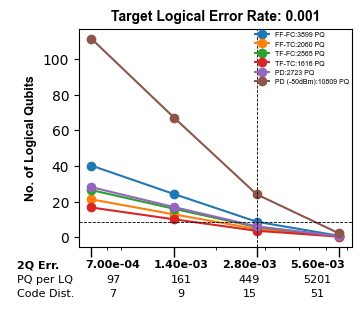

In [11]:
# IEEE TQE Guidelines
# Single column: 3.5" (wide) x 8.5" (height)
# Double column: 7.16" (wide) x 8.5" (height)
fig, ax = plt.subplots(nrows=1, ncols=1, 
                       figsize=(3.5, 3),
                      constrained_layout=True)
ax.set_title(f"Target Logical Error Rate: {target_ler}",fontproperties=title_font)
LQ_dict = {}
for label, val in NPQ.items():
    LQ = [val/rate for rate in  pq_per_lq]
    ax.plot(tq_error, LQ, marker='o', label=label)
    LQ_dict[label] = LQ
    # ax.set_xticks([])
    # ax.set_xticklabels([])

ax.set_xscale('log')
ax.xaxis.set_major_formatter(NullFormatter())
ax.xaxis.set_minor_formatter(NullFormatter())
ax.set_xticks([])
ax.set_xticklabels([])
ax.tick_params(axis='x', which='major', length=7, width=1, direction='out', color='black')
ax.set_xticks(tq_error)
ax.set_xticklabels([])
ax.set_xlabel(None)

# Add a table to the axes
# Table data
formatted_tq_error = [f"{tick:.2e}" for tick in tq_error]
data = [formatted_tq_error, pq_per_lq, d]
rows = ['2Q Err.', 'PQ per LQ', 'Code Dist.']

the_table = ax.table(
    cellText=data,
    rowLabels=rows,
    colLabels=None,
    loc='bottom',
    bbox=[0, -0.25, 1, 0.2], # [x0, y0, width, height] relative to axes
    cellLoc='center',
    edges='open',
)
# Adjust font size of the table to fit the small figure
the_table.auto_set_font_size(False)
the_table.set_fontsize(8)


# Bold the first row of the table
# which also serves as the x-ticklabels
for i in range(-1, len(tq_error)):
    cell = the_table[0, i] 
    cell.get_text().set_fontweight('bold')

ax.set_ylabel("No. of Logical Qubits", fontproperties=axis_label_font)

# Rename labels for the legend
handles, labels =  ax.get_legend_handles_labels()

new_labels = []
for label in labels:
    new_label = f"{label}:{NPQ[label]} PQ"
    new_labels.append(new_label)
ax.legend(labels = new_labels,
          ncol=1,
          bbox_to_anchor=(1,1),
          loc='upper right',
          prop=legend_font,
          frameon=False,
          borderaxespad=0.)

ax.axhline(y=LQ_dict['FF-FC'][2], color='k', linestyle='--',linewidth=0.6)
ax.axvline(x=2.8e-3, color='k', linestyle='--',linewidth=0.6)

plt.savefig(f"./LER_2Q_lp.png",dpi=600)
plt.show()